In [ ]:
import os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="keras.src.export.tf2onnx_lib"
)
import tensorflow as tf
import pandas as pd
from src.constants import *
from src.helpers import load_img, build_dataset, decode_model_output, load_MY_model, get_encode_funs, CTCLayer
import editdistance
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(TEST_TSV, sep='\t', header=None, names=['file', 'label'])
df = df.dropna(subset=['label']).reset_index(drop=True)
image_paths = [TEST_DIR + "/" + f for f in df["file"].values]
labels = df["label"].values

In [3]:
label_to_int, label_to_str = get_encode_funs()
#model = load_MY_model()
model = tf.keras.saving.load_model(MODEL_FILE, custom_objects={"CTCLayer": CTCLayer})
test_ds = build_dataset(image_paths, labels, 32, label_to_int)
pred_y = model.predict(test_ds)

I0000 00:00:1769347902.208942   19352 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6053 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step


In [ ]:
truths = []
preds = []
preds_probs = []
for imgs, labels in test_ds:
    pred = model(imgs, training=False)
    preds_probs.append(pred)
    preds.extend(decode_model_output(pred, label_to_str))
    for seq in labels.numpy():
        seq = seq[seq != 0]
        truths.append(b"".join(label_to_str(seq).numpy()).decode("utf-8"))

total_edits = 0
total_chars = 0
for p, t in zip(preds, truths):
    total_edits += editdistance.eval(p, t)
    total_chars += len(t)
cer = total_edits / max(1, total_chars)

correct = sum(p == t for p, t in zip(preds, truths))
ewm = correct / max(1, len(truths))

logits = tf.concat(preds_probs, axis=0)
pred_ids = tf.argmax(logits, axis=-1)
blank_idx = logits.shape[-1] - 1
blanks = tf.equal(pred_ids, blank_idx)
blank_cnt = tf.reduce_sum(tf.cast(blanks, tf.float32))
total_steps = tf.cast(tf.size(pred_ids), tf.float32)
blank_ratio = (blank_cnt / tf.maximum(1., total_steps)).numpy()

pred_lengths = [len(p) for p in preds]
truth_lengths = [len(t) for t in truths]
len_ratio = sum(pred_lengths) / max(1, sum(truth_lengths))

print(f"Cer: {cer}")
print(f"Ewm: {ewm}")
print(f"Blank ratio: {blank_ratio}")
print(f"Length ratio: {len_ratio}")

/home/silver/tf-venv310/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: img_input
Received: inputs=['Tensor(shape=(8, 200, 800, 1))']
  warnings.warn(msg)


Cer: 0.5657335581787521
Ewm: 0.03562176165803109
Blank ratio: 0.8150777220726013
Length ratio: 0.8956492411467116


In [ ]:
df = pd.read_csv(TRAIN_TSV, sep='\t', header=None, names=['file', 'label'])
df = df.dropna(subset=['label']).reset_index(drop=True)
image_paths = [TRAIN_DIR + "/" + f for f in df["file"].values]
labels = df["label"].values

model = load_MY_model()

testing = build_dataset(image_paths[:100], labels[:100], 100, label_to_int)

preds = model.predict(testing)

predicted_labels = decode_model_output(preds, label_to_str)
for idx, truth in enumerate(predicted_labels):
    if labels[idx] == predicted_labels[idx]:
        print(idx, truth)

/home/silver/tf-venv310/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: img_input
Received: inputs=['Tensor(shape=(100, 200, 800, 1))']
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
6 миф
10 богу
11 об
14 ведут
18 Восточное
19 Речь
20 Малая
24 нет
27 рек,
39 река
44 ход
46 нет
47 эпохи
50 из
52 семитов
53 но
56 31
59 да
60 было
61 важным
62 т.к.
63 было
65 так
66 соц
67 же
69 не
70 17000
71 на
74 из
78 ная
79 Эбла
80 царя
82 царя.
83 ходили
85 сер.
90 верховным
92 Есть
99 Саргон


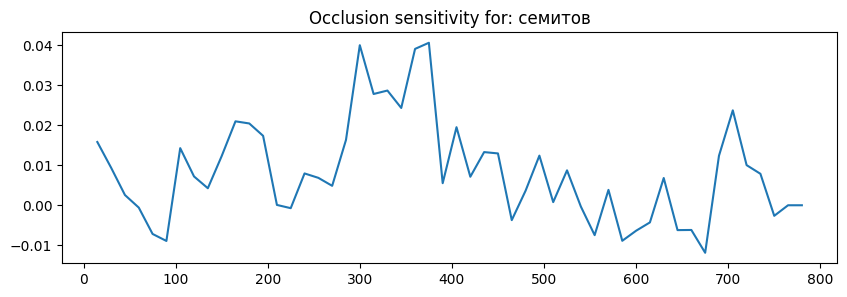

In [ ]:
indices = [10, 18, 52]

img = load_img(image_paths[indices[2]])
img = tf.expand_dims(img, axis=0)
true_label = labels[indices[2]]

def confidence(preds):
    max_probs = tf.reduce_max(preds, axis=-1)
    return tf.reduce_mean(max_probs).numpy()

def occlude(img, x_start, width):
    img_occ = img.numpy().copy()
    img_occ[:, :, x_start:x_start+width, :] = 0.0
    return tf.constant(img_occ)

base_preds = model(img)
base_conf = confidence(base_preds)
base_text = decode_model_output(base_preds, label_to_str)[0]

occ_width = 30
stride = 15

drops = []
xs = []

for x in range(0, IM_WIDTH - occ_width, stride):
    img_occ = occlude(img, x, occ_width)
    preds_occ = model(img_occ)
    conf_occ = confidence(preds_occ)

    drops.append(base_conf - conf_occ)
    xs.append(x + occ_width // 2)

plt.figure(figsize=(10, 3))
plt.plot(xs, drops)
plt.title(f"Occlusion sensitivity for: {base_text}")
plt.show()

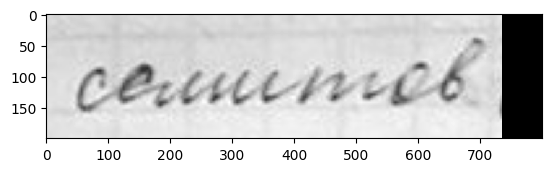

In [26]:
plt.imshow(img[0, :, :, 0], cmap="gray", interpolation="nearest")